In [21]:
#path fixes and imports
import sys
from pathlib import Path
repo_root = Path.cwd().parent.parent

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

print("Repo Root Added:", repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

from Data_Pipeline.cleaning import SimpleImputer
from Data_Pipeline.scaling import StandardScaler
from Data_Pipeline.split import train_test_split

Repo Root Added: c:\Users\dheem\OneDrive\Desktop\machine-learning-from-scratch


In [22]:
#loading data set
df = pd.read_csv(
    "data/covertype.csv"
)
print(df.shape)
df.head()

(581012, 55)


,Cover_Type,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,5,2596,51,3,258,0,510,221,232,148,...,0,0,0,0,0,0,0,0,0,0
1,5,2590,56,2,212,-6,390,220,235,151,...,0,0,0,0,0,0,0,0,0,0
2,2,2804,139,9,268,65,3180,234,238,135,...,0,0,0,0,0,0,0,0,0,0
3,2,2785,155,18,242,118,3090,238,238,122,...,0,0,0,0,0,0,0,0,0,0
4,5,2595,45,2,153,-1,391,220,234,150,...,0,0,0,0,0,0,0,0,0,0


Classes: [0 1]


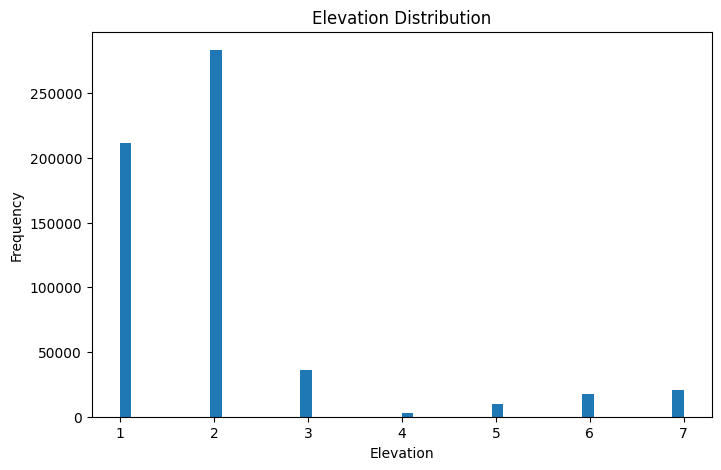

In [23]:
#features and visualization
X_raw = df.iloc[:, :-1].values.astype(float)
y_raw = df.iloc[:, -1].astype(int).values

# Automatically handle label indexing
if y_raw.min() == 1:
    y_raw = y_raw - 1

print("Classes:", np.unique(y_raw))

plt.figure(figsize=(8,5))
plt.hist(
    X_raw[:,0],
    bins=50
)
plt.title("Elevation Distribution")
plt.xlabel("Elevation")
plt.ylabel("Frequency")
plt.show()

In [24]:
#cleaning, splitting and adding missing values 
missing_indices = np.random.choice(
    X_raw.size,
    int(0.01 * X_raw.size),
    replace=False
)
X_raw.flat[missing_indices] = np.nan

imputer = SimpleImputer(
    strategy="mean"
)
X_clean = imputer.fit_transform(X_raw)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_raw,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(464809, 54)
(116203, 54)


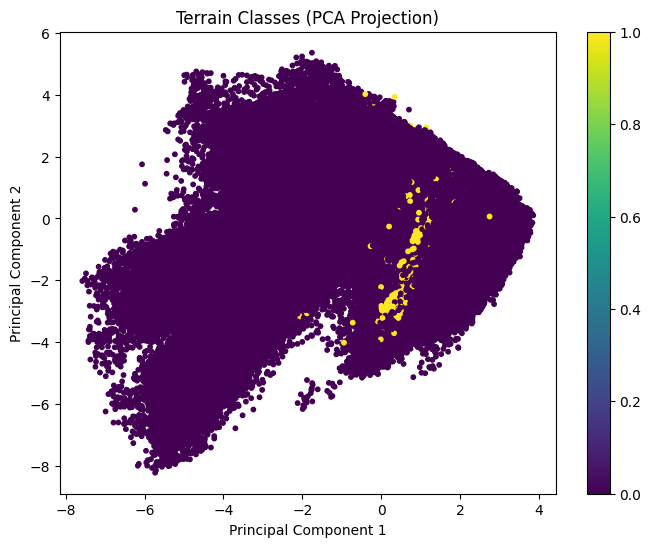

In [25]:
#PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_raw,
    s=10
)

plt.title("Terrain Classes (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter)
plt.show()

In [26]:
# Tensors conversion
# Convert features to 32-bit float and labels to 1D Long integer vectors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # Uses original 0-6 integer array

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [27]:
#NN model
class TerrainClassifierPyTorch(nn.Module):
    def __init__(self, input_dim, hidden_1, hidden_2, output_dim):
        super(TerrainClassifierPyTorch, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_2, output_dim) # Outputs raw logits
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out) # NO Softmax here! CrossEntropyLoss handles it.
        return out

# Instantiation
model = TerrainClassifierPyTorch(input_dim=X_train.shape[1], hidden_1=64, hidden_2=32, output_dim=7)
criterion = nn.CrossEntropyLoss() # Automatically handles LogSoftmax internally
optimizer = optim.Adam(model.parameters(), lr=0.01)

#training loop
losses = []
accuracies = []
epochs = 20
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(
        outputs,
        y_train_tensor
    )
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    _, predictions = torch.max(
        outputs,
        1
    )
    accuracy = (
        predictions == y_train_tensor
    ).float().mean()
    accuracies.append(
        accuracy.item()
    )
    if epoch % 5 == 0:
        print(
            f"Epoch {epoch} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

Epoch 0 | Loss: 1.8666 | Accuracy: 0.1430
Epoch 5 | Loss: 0.2694 | Accuracy: 0.9848
Epoch 10 | Loss: 0.1012 | Accuracy: 0.9848
Epoch 15 | Loss: 0.0838 | Accuracy: 0.9848


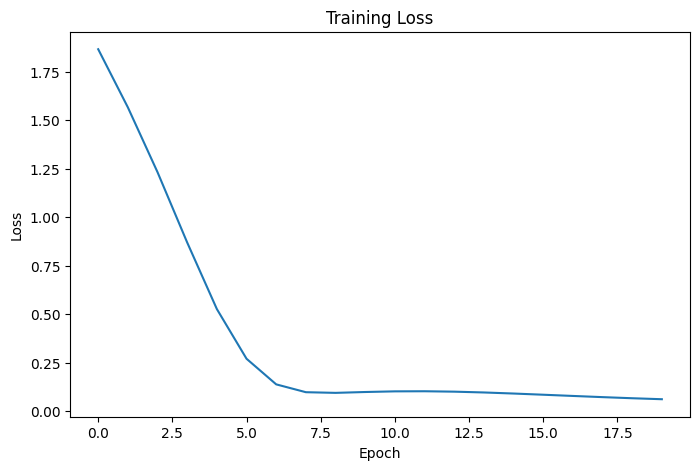

In [28]:
#loss curve 
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

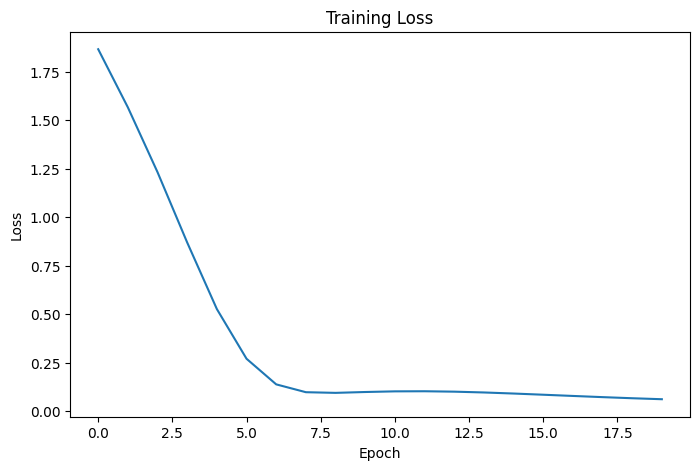

In [29]:
#accuracy curve 
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [30]:
#evaluation
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predictions = torch.max(
        outputs,
        1
    )
    test_accuracy = (
        predictions == y_test_tensor
    ).float().mean()

print(
    "Test Accuracy:",
    test_accuracy.item()
)

Test Accuracy: 0.9854048490524292


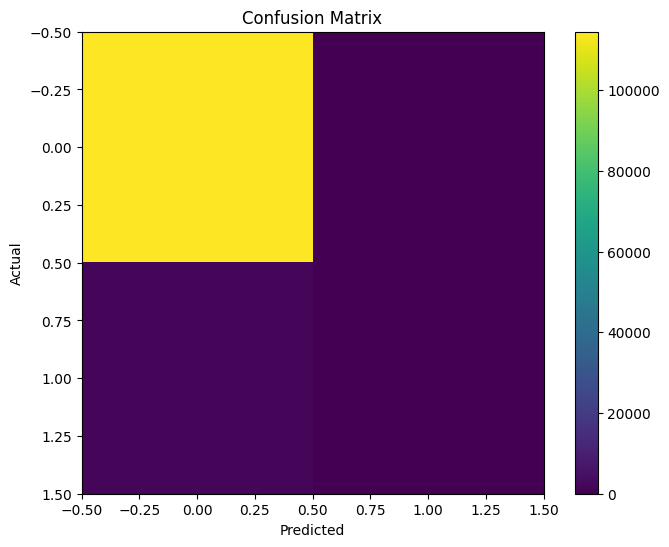

In [31]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    predictions.numpy()
)
plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [32]:
#prediction comparison
for i in range(20):

    print(
        f"Actual: {y_test[i]} | "
        f"Predicted: {predictions[i].item()}"
    )



Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0


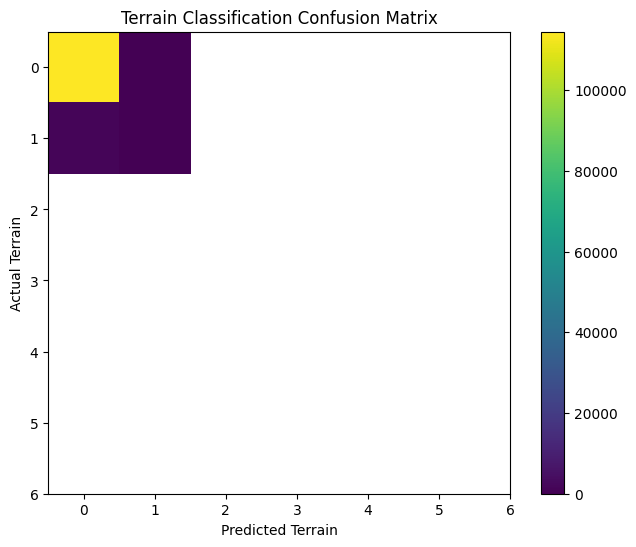

In [33]:
plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Terrain Classification Confusion Matrix")
plt.xlabel("Predicted Terrain")
plt.ylabel("Actual Terrain")
plt.xticks(range(7))
plt.yticks(range(7))
plt.colorbar()
plt.show()